In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, SpectralClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [2]:
from sklearn.datasets import make_blobs

X_raw, _ = make_blobs(n_samples=200, centers=[
    [20, 70], [55, 55], [90, 15], [25, 15], [85, 80]
], cluster_std=[8, 6, 7, 6, 7], random_state=42)

df = pd.DataFrame(X_raw, columns=['Annual_Income', 'Spending_Score'])
df['Annual_Income']   = df['Annual_Income'].clip(15, 140).round(1)
df['Spending_Score']  = df['Spending_Score'].clip(1, 100).round(1)

print("Shape :", df.shape)
df.head()

Shape : (200, 2)


,Annual_Income,Spending_Score
0,63.4,46.6
1,53.8,56.8
2,31.7,68.2
3,87.3,74.2
4,91.5,6.3


In [ ]:
df.describe()

,Annual_Income,Spending_Score
count,200.000000,200.000000
mean,55.292500,47.267000
std,29.592432,28.043391
min,15.000000,1.900000
25%,25.350000,18.275000
50%,54.900000,54.750000
75%,85.425000,73.175000
max,106.200000,94.600000


In [4]:
df.isnull().sum()

Annual_Income     0
Spending_Score    0
dtype: int64

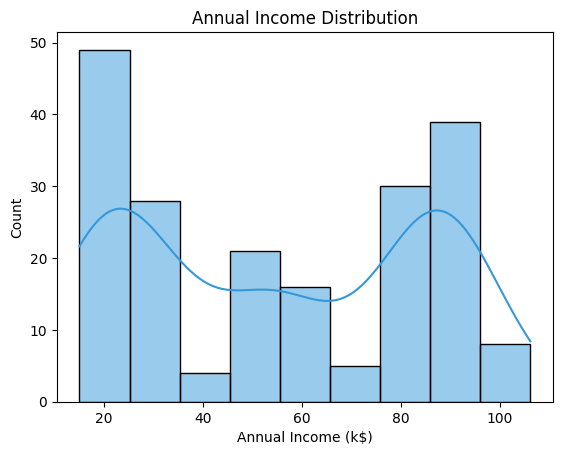

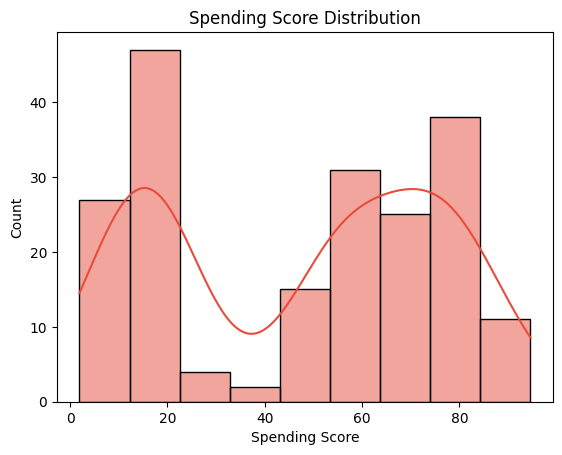

In [5]:
sns.histplot(df['Annual_Income'], kde=True, color='#3498db')
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.show()

sns.histplot(df['Spending_Score'], kde=True, color='#e74c3c')
plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.show()

In [6]:
X = df[['Annual_Income', 'Spending_Score']].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

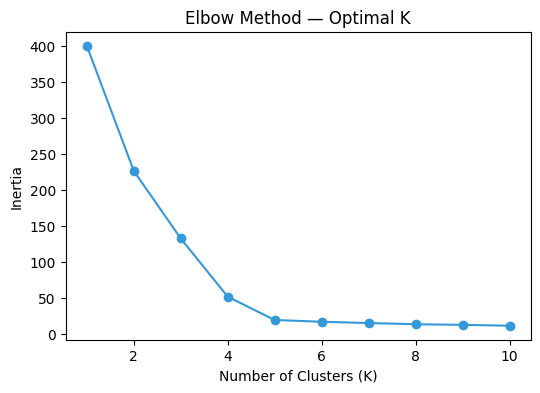

In [7]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))

plt.plot(k_range, inertia, 'o-', color='#3498db')

plt.title("Elbow Method — Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.show()

In [8]:
kmeans_model = KMeans(n_clusters=5, random_state=0, n_init=10)

kmeans_labels = kmeans_model.fit_predict(X)

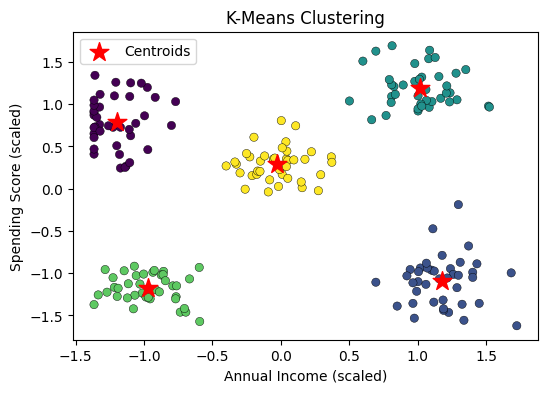

In [9]:
plt.figure(figsize=(6,4))

plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis', edgecolors='black', linewidth=0.3)
plt.scatter(kmeans_model.cluster_centers_[:, 0],
            kmeans_model.cluster_centers_[:, 1],
            s=200, c='red', marker='*', label='Centroids')

plt.title("K-Means Clustering")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.legend()

plt.show()

In [10]:
spectral_model = SpectralClustering(n_clusters=5, affinity='rbf', random_state=0)

spectral_labels = spectral_model.fit_predict(X)

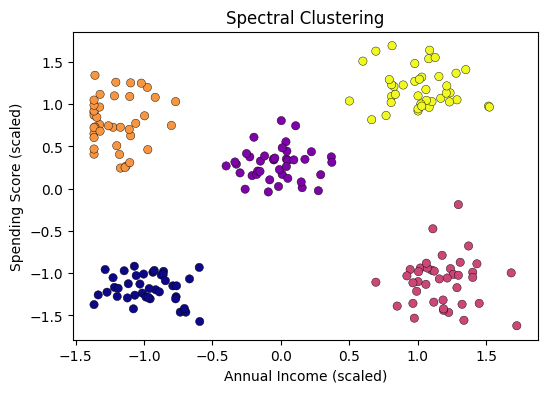

In [11]:
plt.figure(figsize=(6,4))

plt.scatter(X[:, 0], X[:, 1], c=spectral_labels, cmap='plasma', edgecolors='black', linewidth=0.3)

plt.title("Spectral Clustering")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")

plt.show()

In [12]:
dbscan_model = DBSCAN(eps=0.4, min_samples=5)

dbscan_labels = dbscan_model.fit_predict(X)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise     = list(dbscan_labels).count(-1)

print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise}")

Clusters found : 5
Noise points   : 1


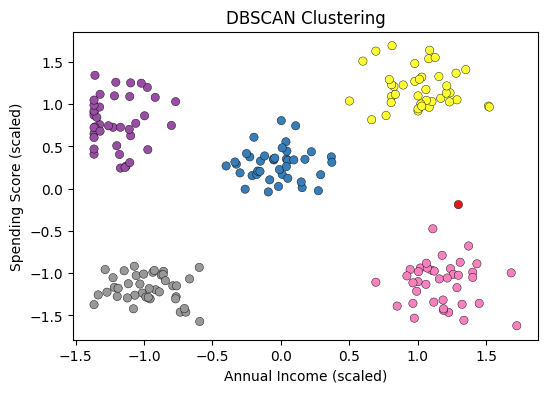

In [13]:
plt.figure(figsize=(6,4))

plt.scatter(X[:, 0], X[:, 1], c=dbscan_labels, cmap='Set1', edgecolors='black', linewidth=0.3)

plt.title("DBSCAN Clustering")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")

plt.show()

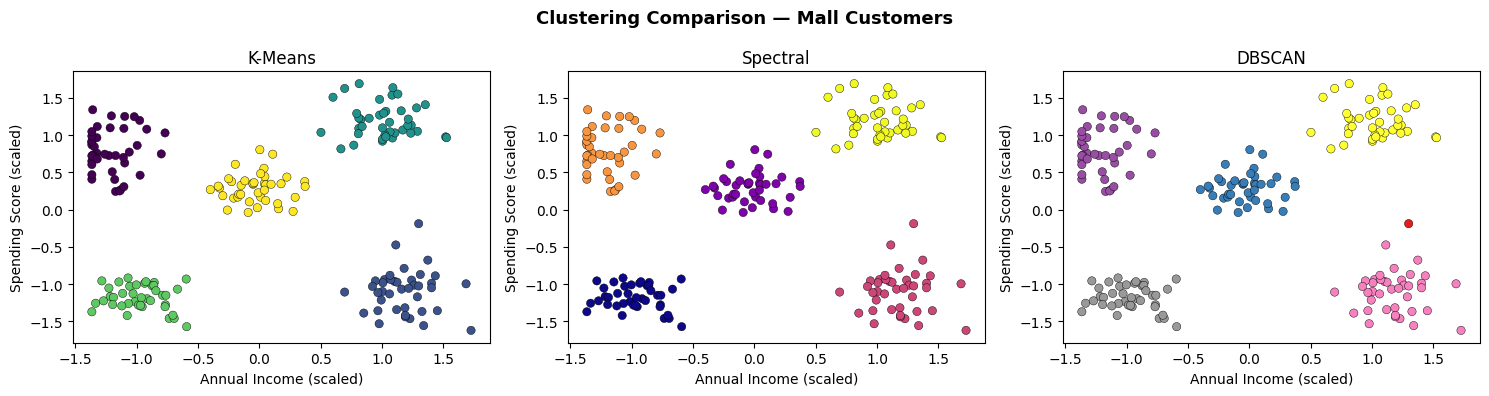

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets = [
    (kmeans_labels,   'viridis', "K-Means"),
    (spectral_labels, 'plasma',  "Spectral"),
    (dbscan_labels,   'Set1',    "DBSCAN"),
]

for ax, (labels, cmap, title) in zip(axes, datasets):
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap=cmap,
               edgecolors='black', linewidth=0.3)
    ax.set_title(title)
    ax.set_xlabel("Annual Income (scaled)")
    ax.set_ylabel("Spending Score (scaled)")

plt.suptitle("Clustering Comparison — Mall Customers", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
mask = dbscan_labels != -1

results = {
    "Model"             : ["K-Means", "Spectral", "DBSCAN"],
    "Silhouette Score"  : [
        silhouette_score(X, kmeans_labels),
        silhouette_score(X, spectral_labels),
        silhouette_score(X[mask], dbscan_labels[mask])
    ],
    "Davies-Bouldin"    : [
        davies_bouldin_score(X, kmeans_labels),
        davies_bouldin_score(X, spectral_labels),
        davies_bouldin_score(X[mask], dbscan_labels[mask])
    ],
    "Calinski-Harabasz" : [
        calinski_harabasz_score(X, kmeans_labels),
        calinski_harabasz_score(X, spectral_labels),
        calinski_harabasz_score(X[mask], dbscan_labels[mask])
    ],
}

df_results = pd.DataFrame(results).set_index("Model")
print(df_results.to_string())

          Silhouette Score  Davies-Bouldin  Calinski-Harabasz
Model                                                        
K-Means           0.731015        0.360184         965.068245
Spectral          0.731015        0.360184         965.068245
DBSCAN            0.734490        0.358178        1002.398692


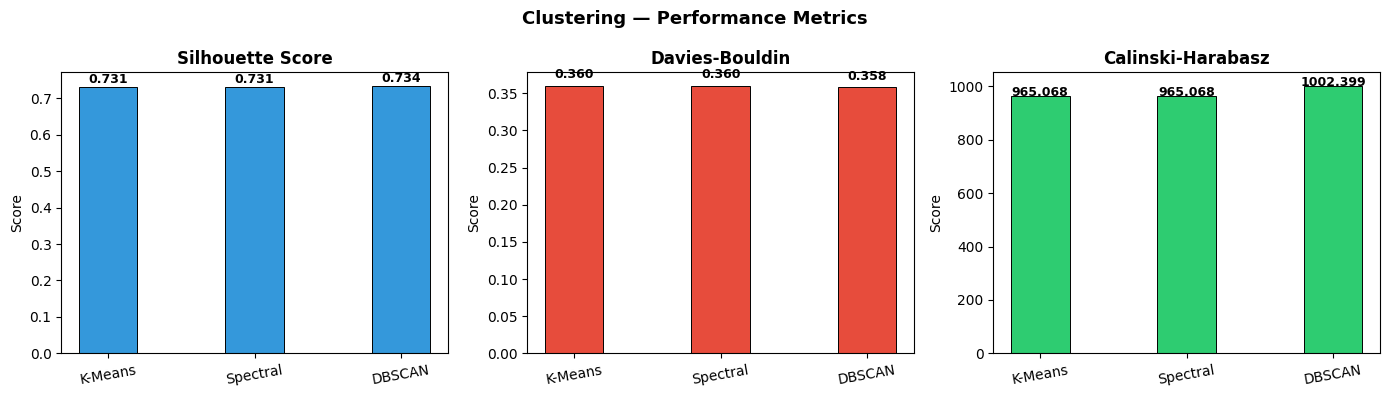

In [16]:
metrics = ["Silhouette Score", "Davies-Bouldin", "Calinski-Harabasz"]
models  = df_results.index.tolist()
colors  = ['#3498db', '#e74c3c', '#2ecc71']
x       = np.arange(len(models))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, metric, color in zip(axes, metrics, colors):
    vals = df_results[metric].astype(float)
    bars = ax.bar(x, vals, color=color, edgecolor='black', linewidth=0.7, width=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=10)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel("Score")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{bar.get_height():.3f}",
                ha='center', fontsize=9, fontweight='bold')

plt.suptitle("Clustering — Performance Metrics", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

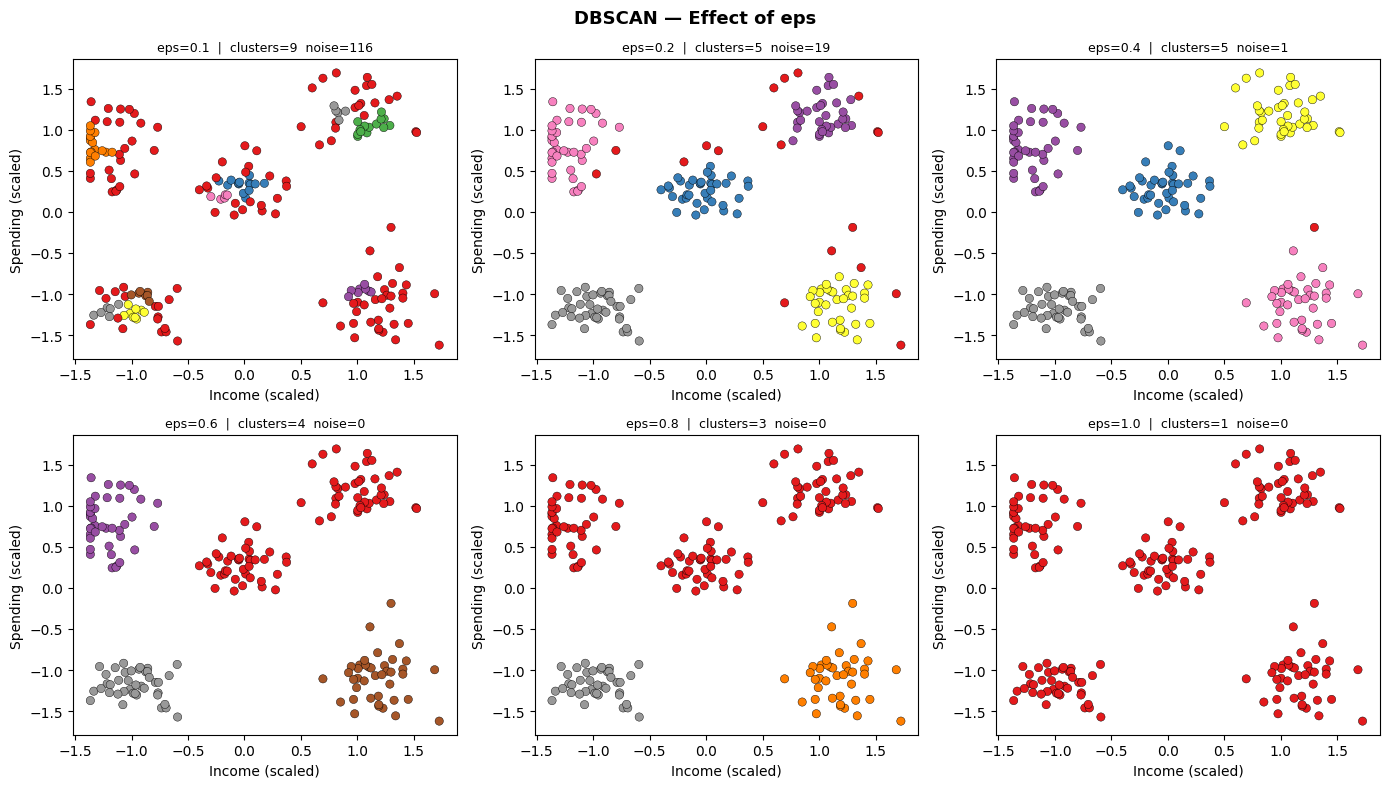

In [17]:
eps_values = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, eps in zip(axes, eps_values):
    labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X)
    n_cls  = len(set(labels)) - (1 if -1 in labels else 0)
    noise  = list(labels).count(-1)
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='Set1',
               edgecolors='black', linewidth=0.3)
    ax.set_title(f"eps={eps}  |  clusters={n_cls}  noise={noise}", fontsize=9)
    ax.set_xlabel("Income (scaled)")
    ax.set_ylabel("Spending (scaled)")

plt.suptitle("DBSCAN — Effect of eps", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

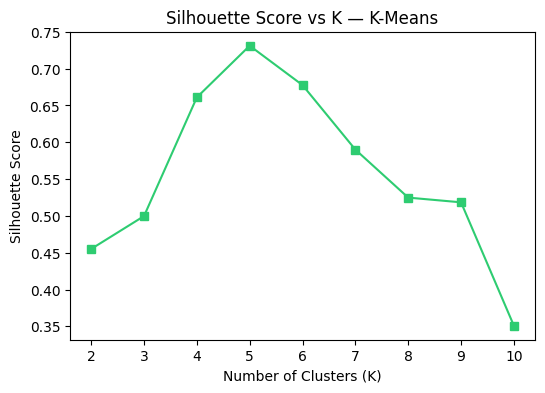

In [18]:
sil_scores = []
k_range    = range(2, 11)

for k in k_range:
    labels = KMeans(n_clusters=k, random_state=0, n_init=10).fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

plt.figure(figsize=(6,4))

plt.plot(k_range, sil_scores, 's-', color='#2ecc71')

plt.title("Silhouette Score vs K — K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.show()